<a href="https://colab.research.google.com/github/ryrynbob/ust-deep-learning-2026/blob/main/Assignment_Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Week 8

##Professor Simon

## Ryan Nguyen


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import kagglehub

# These are necessary hyperparameters
IMG_SIZE = 64
LATENT_DIM = 128
BETA = 4.0

In [2]:

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:


# 1. Use the path kagglehub gave you
# It likely looks like: /root/.cache/kagglehub/datasets/...
base_path = path

# 2. Load the attributes CSV
# The CSV is usually in the base folder
csv_path = os.path.join(base_path, 'list_attr_celeba.csv')
train_labels = pd.read_csv(csv_path)

print("Attributes loaded. Total rows:", len(train_labels))

In [5]:
def load_images_refined(num_images=30000):
    images = []
    # In the kagglehub download, the images are usually in this subfolder:
    img_folder = os.path.join(base_path, 'img_align_celeba', 'img_align_celeba')

    print(f"Loading {num_images} images from {img_folder}...")

    for i in range(1, num_images + 1):
        img_name = f"{i:06d}.jpg"
        full_path = os.path.join(img_folder, img_name)

        img = cv2.imread(full_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (64, 64))
            images.append(img)

        if i % 10000 == 0:
            print(f"Loaded {i}...")

    return np.array(images) / 255.0

# This is your main image array for the homework
train_images = load_images_refined(30000)

Loading 30000 images from /kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba...
Loaded 10000...
Loaded 20000...
Loaded 30000...


In [9]:
# 1. The Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. The Encoder
encoder_inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 3. The Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(16 * 16 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((16, 16, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# 4. The VAE Class
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + BETA * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# Now we create the 'vae' object
vae = VAE(encoder, decoder)

In [10]:
vae.compile(optimizer='adam')

# Train with the data you loaded from kagglehub
vae.fit(train_images, epochs=10, batch_size=128)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - kl_loss: 4.9708 - loss: 2605.6277 - reconstruction_loss: 2585.7446
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - kl_loss: 7.9139 - loss: 2481.6187 - reconstruction_loss: 2449.9631
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - kl_loss: 9.7418 - loss: 2442.6887 - reconstruction_loss: 2403.7217
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - kl_loss: 9.0372 - loss: 2427.5459 - reconstruction_loss: 2391.3970
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - kl_loss: 8.0126 - loss: 2416.7341 - reconstruction_loss: 2384.6838
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - kl_loss: 7.5442 - loss: 2411.5825 - reconstruction_loss: 2381.4060
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - kl_loss: 7.4405 - loss: 2407.6313 - reconstruction_loss: 2377.8694
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - kl_loss: 7.2483 - loss: 2402.7241 - reconstruction_loss: 2373.7310
Epoch 9/10
235/235 ━━━━━

In [12]:
# Save so you never have to wait 50 minutes again
# Explicitly build the VAE model before saving weights
# The input shape should match the shape of your images (batch_size, height, width, channels)
vae.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
vae.save_weights('vae_trained_weights.weights.h5')
print("Weights saved safely.")

Weights saved safely.


In [13]:
def get_attr_vector(attr_name, num_samples=1500):
    # Get indices for Positive and Negative examples
    # (CelebA uses 1 and -1)
    pos_idx = train_labels[train_labels[attr_name] == 1].index
    neg_idx = train_labels[train_labels[attr_name] == -1].index

    # Only use indices that exist in our loaded train_images (first 30k)
    pos_idx = [i for i in pos_idx if i < 30000][:num_samples]
    neg_idx = [i for i in neg_idx if i < 30000][:num_samples]

    # Batch predict to keep it fast and memory-safe
    z_pos = encoder.predict(train_images[pos_idx], batch_size=64)
    z_neg = encoder.predict(train_images[neg_idx], batch_size=64)

    # The 'concept vector' is the average difference
    return np.mean(z_pos[0], axis=0) - np.mean(z_neg[0], axis=0)

# Calculate all 4 required vectors at once
print("Calculating attribute vectors...")
v_smile   = get_attr_vector('Smiling')
v_glasses = get_attr_vector('Eyeglasses')
v_blonde  = get_attr_vector('Blond_Hair')
v_gender  = get_attr_vector('Male')
print("Vectors ready!")

Calculating attribute vectors...
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Vectors ready!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


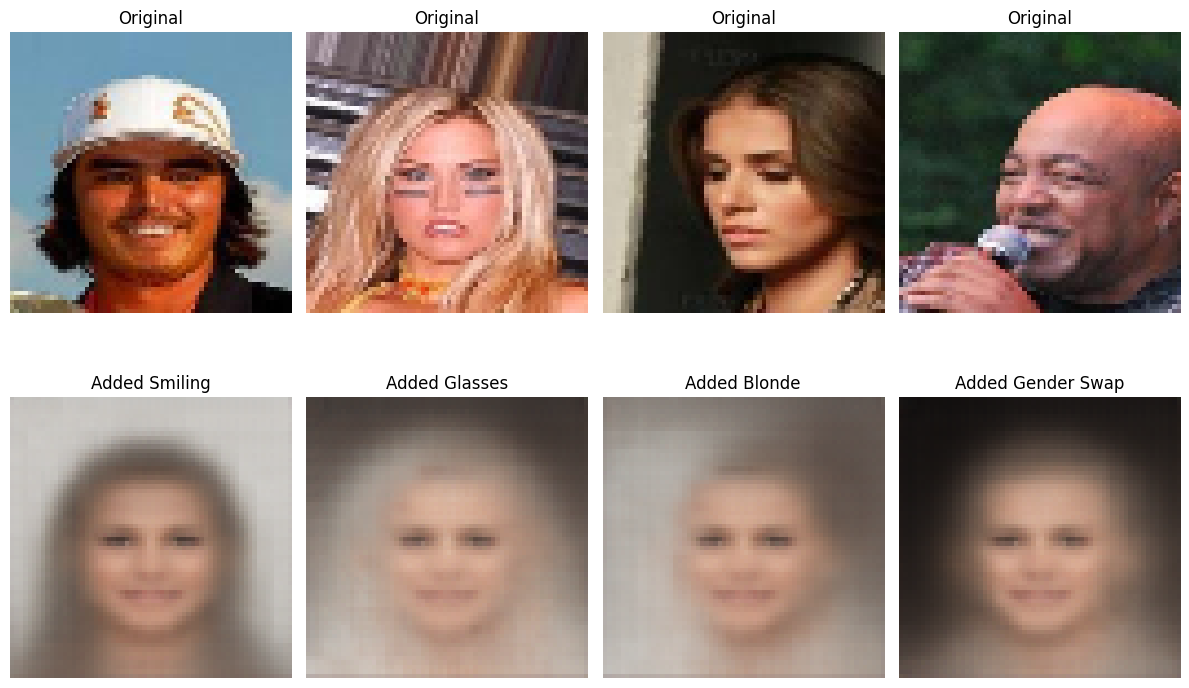

In [14]:
def apply_arithmetic(target_vector, alpha=2.0):
    # 1. Pick a random face from the test set (images we didn't use for vectors)
    idx = np.random.randint(25000, 30000)
    original_img = train_images[idx:idx+1]

    # 2. Encode to latent space
    z_mean, z_log_var, z = encoder.predict(original_img)

    # 3. Add the attribute (Math: Original + Strength * Vector)
    z_morphed = z_mean + (alpha * target_vector)

    # 4. Decode back to pixels
    morphed_img = decoder.predict(z_morphed)
    return original_img[0], morphed_img[0]

# Generate the 4 required transformations
attrs = [("Smiling", v_smile), ("Glasses", v_glasses),
         ("Blonde", v_blonde), ("Gender Swap", v_gender)]

plt.figure(figsize=(12, 8))
for i, (name, vec) in enumerate(attrs):
    orig, morphed = apply_arithmetic(vec)

    plt.subplot(2, 4, i+1)
    plt.title(f"Original")
    plt.imshow(orig); plt.axis('off')

    plt.subplot(2, 4, i+5)
    plt.title(f"Added {name}")
    plt.imshow(morphed); plt.axis('off')

plt.tight_layout()
plt.show()